In [1]:
import sys, subprocess, psutil, importlib, os, glob, re
sys.path.insert(0, '/home/581/da1339/AFIM/src/python')
import AFIM
#import xesmf            as xe
import numpy             as np
import pandas            as pd
import xarray            as xr
import metpy.calc        as mpc
import cmocean           as cm
import seaborn           as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.path   as mpath
import cartopy.crs       as ccrs
import cartopy.feature   as cft
from datetime            import timedelta, date, datetime
from shapely.geometry    import box
from shapely.ops         import transform
#from pyproj              import Geod
#from concurrent.futures  import ThreadPoolExecutor
%matplotlib inline
memory_info = psutil.virtual_memory()
print(f"Available memory: {memory_info.available} bytes")
print(f"Available memory: {memory_info.available / (1024 ** 2)} MB")
print(f"Available memory: {memory_info.available / (1024 ** 3)} GB")

Available memory: 1023542726656 bytes
Available memory: 976126.41015625 MB
Available memory: 953.2484474182129 GB


# SIA and SIE

In [2]:
afim_anal = AFIM.analysis()

## Helpful functions

In [45]:
def compute_static_ice(ds, hemisphere='SH', stic=False, stia=False, stie=False, P_stic=None, P_stia=None, P_stie=None):
    """
    Compute static (landfast) ice concentration and/or area and/or extent.

    Parameters:
    ds (xarray.Dataset): The dataset containing the necessary variables.
    hemisphere (str): 'SH' for Southern Hemisphere or 'NH' for Northern Hemisphere. Default is 'SH'.
    stic (bool): If True, compute and return static ice concentration.
    stia (bool): If True, compute and return static ice area.
    stie (bool): If True, compute and return static ice extent.
    P_stic (str): Path to save the static ice concentration NetCDF file. If None, results are not saved. Default is None.
    P_stia (str): Path to save the static ice area NetCDF file. If None, results are not saved. Default is None.
    P_stie (str): Path to save the static ice extent NetCDF file. If None, results are not saved. Default is None.

    Returns:
    tuple: (xarray.DataArray, xarray.DataArray, xarray.DataArray)
           Static ice concentration, static ice area, and static ice extent depending on the parameters.
    """
    # Helper function to mask and resample variables
    def mask_and_resample(var_name, grid_type, hemisphere, ds):
        return afim_anal.mask_hemisphere(ds, var_name=var_name, grid_type=grid_type, hemisphere=hemisphere).sortby('time').resample(time='2W').mean()
    # Load and process variables
    uvel = mask_and_resample('uvel', 'u', hemisphere, ds)
    vvel = mask_and_resample('vvel', 'u', hemisphere, ds)
    aice = mask_and_resample('aice', 't', hemisphere, ds)
    # Compute ice speed
    ispd = np.sqrt(uvel**2 + vvel**2)
    # Create static ice mask
    mask_stic = (aice > afim_anal.aice_thresh) & (ispd < afim_anal.stic_thresh)
    stic_result = None
    stia_result = None
    stie_result = None
    # Compute static ice concentration    
    if stic:
        stic_result = aice.where(mask_stic)
        if P_stic:
            if os.path.exists(P_stic): os.remove(P_stic)
            stic_result.to_netcdf(P_stic)
    # Compute static ice area
    if stia:
        area = afim_anal.mask_hemisphere(ds, var_name='uarea', grid_type='u', hemisphere=hemisphere)
        stia_result = area.where(mask_stic).sum(dim=['nj', 'ni']) / 1e9  # Convert to 10^6 km^2
        if P_stia:
            if os.path.exists(P_stia): os.remove(P_stia)
            stia_result.to_netcdf(P_stia)
    # Compute static ice extent
    if stie:
        area = afim_anal.mask_hemisphere(ds, var_name='uarea', grid_type='u', hemisphere=hemisphere)
        stie_result = mask_stic.sum(dim=['nj', 'ni'], skipna=True) / 1e9  # Convert to 10^6 km^2
        if P_stie:
            if os.path.exists(P_stie): os.remove(P_stie)
            stie_result.to_netcdf(P_stie)
    # return results
    return stic_result, stia_result, stie_result

## NSIDC

In [ ]:
F_nsidc = afim_anal.find_files( afim_anal.D_NSIDC, ds_type='nsidc' )
NSIDC = xr.open_mfdataset(F_nsidc, concat_dim='tdim', combine='nested').swap_dims(tdim='time').compute()
aice = NSIDC['cdr_seaice_conc']
for flag in afim_anal.NSIDC_flags:
    aice = xr.where(aice == flag / 100, np.nan, aice)
cell_area = xr.open_dataset(afim_anal.P_NSIDC_cell_area).cell_area
mask = aice > afim_anal.aice_thresh
NSIDC_SIA = (aice * cell_area).where(mask).sum(dim=['y', 'x'], skipna=True) / 1e12
NSIDC_SIE = (mask * cell_area).sum(dim=['y', 'x'], skipna=True) / 1e12
NSIDC_SIA.to_netcdf("/g/data/jk72/da1339/tmp/NSIDC_SIA.nc")
NSIDC_SIE.to_netcdf("/g/data/jk72/da1339/tmp/NSIDC_SIE.nc")

## AOM2

In [40]:
redo = True
P_aom2_era5      = f"{afim_anal.D_tmp}/AOM2_era5.nc"
P_aom2_jra55     = f"{afim_anal.D_tmp}/AOM2_jra55.nc"
P_aom2_era5_sia  = f"{afim_anal.D_tmp}/AOM2_era5_SIA.nc"
P_aom2_era5_sie  = f"{afim_anal.D_tmp}/AOM2_era5_SIE.nc"
P_aom2_jra55_sia = f"{afim_anal.D_tmp}/AOM2_jra55_SIA.nc"
P_aom2_jra55_sie = f"{afim_anal.D_tmp}/AOM2_jra55_SIE.nc"
if redo:
    F_era5         = afim_anal.find_files(afim_anal.D_AOM2_local, ds_type='aom2', frcg='era5')
    aom2_era5      = xr.open_mfdataset(F_era5, concat_dim='time', combine='nested')[afim_anal.cice_stic_vars]
    F_jra55        = afim_anal.find_files(afim_anal.D_AOM2_local, ds_type='aom2', frcg='jra55')
    aom2_jra55     = xr.open_mfdataset(F_jra55, concat_dim='time', combine='nested')[afim_anal.cice_stic_vars]
    aom2_era5_hem  = afim_anal.mask_hemisphere(aom2_era5, var_name='aice', grid_type='t')
    aom2_jra55_hem = afim_anal.mask_hemisphere(aom2_jra55, var_name='aice', grid_type='t')
    aom2_era5_SIA  = afim_anal.compute_sia_or_sie(aom2_era5_hem, DS_name='AOM2', sia_or_sie='sia', var_name='aice', area=aom2_era5.tarea, aice_thresh=afim_anal.aice_thresh)
    aom2_era5_SIE  = afim_anal.compute_sia_or_sie(aom2_era5_hem, DS_name='AOM2', sia_or_sie='sie', var_name='aice', area=aom2_era5.tarea, aice_thresh=afim_anal.aice_thresh)
    aom2_jra55_SIA = afim_anal.compute_sia_or_sie(aom2_jra55_hem, DS_name='AOM2', sia_or_sie='sia', var_name='aice', area=aom2_jra55.tarea, aice_thresh=afim_anal.aice_thresh)
    aom2_jra55_SIE = afim_anal.compute_sia_or_sie(aom2_jra55_hem, DS_name='AOM2', sia_or_sie='sie', var_name='aice', area=aom2_jra55.tarea, aice_thresh=afim_anal.aice_thresh)
    os.system(f"rm {P_aom2_era5}")
    os.system(f"rm {P_aom2_jra55}")
    os.system(f"rm {P_aom2_era5_sia}")
    os.system(f"rm {P_aom2_era5_sie}")
    os.system(f"rm {P_aom2_jra55_sia}")
    os.system(f"rm {P_aom2_jra55_sie}")
    aom2_era5.to_netcdf(P_aom2_era5)
    aom2_jra55.to_netcdf(P_aom2_jra55)
    aom2_era5_SIA.to_netcdf(P_aom2_era5_sia)
    aom2_era5_SIE.to_netcdf(P_aom2_era5_sia)
    aom2_jra55_SIA.to_netcdf(P_aom2_era5_sia)
    aom2_jra55_SIE.to_netcdf(P_aom2_era5_sia)
else:
    aom2_era5      = xr.open_dataset(P_aom2_era5)
    aom2_jra55     = xr.open_dataset(P_aom2_jra55)
    aom2_era5_SIA  = xr.open_dataset(P_aom2_era5_SIA)
    aom2_era5_SIE  = xr.open_dataset(P_aom2_era5_SIE)
    aom2_jra55_SIA = xr.open_dataset(P_aom2_jra55_SIA)
    aom2_jra55_SIE = xr.open_dataset(P_aom2_jra55_SIE)

Search pattern: /g/data/jk72/da1339/ocn/AOM2/ERA5/ice/0p25/daily/iceh.*-daily.nc
Files found: 312
Found 24 files within the date range.
Search pattern: /g/data/jk72/da1339/ocn/AOM2/JRA55/ice/0p25/daily/iceh.*-daily.nc
Files found: 300
Found 24 files within the date range.


## AFIM

In [4]:
afim_ds = {}
for run_name, run_config in afim_anal.AFIM_runs.items():
    if run_config['anal']:
        F_concat = f"{afim_anal.D_tmp}/AFIM_{run_name}.nc"
        if run_config['concat']:
            F_found  = afim_anal.find_files(run_config['D_'])
            vars_str = ','.join(afim_anal.cice_stic_vars)
            F_list   = ' '.join(F_found)
            nco_cmd  = f"ncrcat -O -v {vars_str} {F_list} {F_concat}"
            os.system(nco_cmd)
        afim_ds[run_name] = xr.open_dataset(F_concat)

Search pattern: /g/data/ol01/da1339/afim_output/RUN_JF16-wocn-d100/history/daily/iceh.*.nc
Files found: 365
Found 365 files within the date range.
Search pattern: /g/data/ol01/da1339/afim_output/RUN_JF16-evp/history/daily/iceh.*.nc
Files found: 730
Found 730 files within the date range.
Search pattern: /g/data/ol01/da1339/afim_output/RUN_JF16-eap/history/daily/iceh.*.nc
Files found: 730
Found 730 files within the date range.
Search pattern: /g/data/ol01/da1339/afim_output/RUN_JF16-cstar21/history/daily/iceh.*.nc
Files found: 730
Found 730 files within the date range.


In [6]:
afim_hem = {}
for run_name, run_config in afim_anal.AFIM_runs.items():
    if run_config['anal']:
        print(f"masking: {run_name}")
        afim_hem[run_name] = afim_anal.mask_hemisphere(afim_ds[run_name], var_name='aice', grid_type='t')

masking: docn_d60
masking: wocn_d60
masking: mocn_d60
masking: wocn_d100
masking: jf16
masking: jf16-ktp6
masking: jf16-d100
masking: jf16-wocn-d100
masking: jf16-evp
masking: jf16-eap
masking: jf16-cstar21


In [7]:
afim_SIA = {}
afim_SIE = {}
for run_name, run_config in afim_anal.AFIM_runs.items():
    if run_config['anal']:
        print(f"computing SIA and SIE on: {run_name}")
        area = afim_ds[run_name]['tarea']
        afim_SIA[run_name] = afim_anal.compute_sia_or_sie(afim_hem[run_name], DS_name='AFIM', sia_or_sie='sia', var_name='aice', area=area, aice_thresh=afim_anal.aice_thresh)
        afim_SIE[run_name] = afim_anal.compute_sia_or_sie(afim_hem[run_name], DS_name='AFIM', sia_or_sie='sie', var_name='aice', area=area, aice_thresh=afim_anal.aice_thresh)

computing SIA and SIE on: docn_d60
computing SIA and SIE on: wocn_d60
computing SIA and SIE on: mocn_d60
computing SIA and SIE on: wocn_d100
computing SIA and SIE on: jf16
computing SIA and SIE on: jf16-ktp6
computing SIA and SIE on: jf16-d100
computing SIA and SIE on: jf16-wocn-d100
computing SIA and SIE on: jf16-evp
computing SIA and SIE on: jf16-eap
computing SIA and SIE on: jf16-cstar21


In [8]:
for run_name, run_config in afim_anal.AFIM_runs.items():
    if run_config['anal']:
        print(f"saving SIA and SIE: {run_name}")
        afim_SIA[run_name].to_netcdf(f"/g/data/jk72/da1339/tmp/AFIM_{run_name}_SIA.nc")
        afim_SIE[run_name].to_netcdf(f"/g/data/jk72/da1339/tmp/AFIM_{run_name}_SIE.nc")

saving SIA and SIE: docn_d60
saving SIA and SIE: wocn_d60
saving SIA and SIE: mocn_d60
saving SIA and SIE: wocn_d100
saving SIA and SIE: jf16
saving SIA and SIE: jf16-ktp6
saving SIA and SIE: jf16-d100
saving SIA and SIE: jf16-wocn-d100
saving SIA and SIE: jf16-evp
saving SIA and SIE: jf16-eap
saving SIA and SIE: jf16-cstar21


In [11]:
P_SIA = []
P_SIE = []
for run_name, run_config in afim_anal.AFIM_runs.items():
    if run_config['anal']:
        P_SIA.append(f"{afim_anal.D_tmp}/AFIM_{run_name}_SIA.nc")
        P_SIE.append(f"{afim_anal.D_tmp}/AFIM_{run_name}_SIE.nc")
P_SIA.append(f"{afim_anal.D_tmp}/AOM2_era5_SIA.nc")
P_SIE.append(f"{afim_anal.D_tmp}/AOM2_era5_SIE.nc") 
P_SIA.append(f"{afim_anal.D_tmp}/AOM2_jra55_SIA.nc")
P_SIE.append(f"{afim_anal.D_tmp}/AOM2_jra55_SIE.nc")
P_SIA.append(f"{afim_anal.D_tmp}/NSIDC_SIA.nc")
P_SIE.append(f"{afim_anal.D_tmp}/NSIDC_SIE.nc")
#SIA
datasets = []
variable_names = []
for fp in P_SIA:
    ds = xr.open_dataset(fp)
    var_name = list(ds.data_vars.keys())[0]  # Get the variable name
    ds = ds.rename({var_name: fp.split('/')[-1].split('.')[0]})  # Rename the variable to make it unique
    datasets.append(ds)
    variable_names.append(fp.split('/')[-1].split('.')[0])
SIA = xr.merge(datasets, join='outer')
SIA = SIA.fillna(np.nan)
SIA.to_netcdf("/g/data/jk72/da1339/tmp/SIA_1993-94.nc")
#SIE
datasets = []
variable_names = []
for fp in P_SIE:
    ds = xr.open_dataset(fp)
    var_name = list(ds.data_vars.keys())[0]  # Get the variable name
    ds = ds.rename({var_name: fp.split('/')[-1].split('.')[0]})  # Rename the variable to make it unique
    datasets.append(ds)
    variable_names.append(fp.split('/')[-1].split('.')[0])
SIE = xr.merge(datasets, join='outer')
SIE = SIE.fillna(np.nan)
SIE.to_netcdf("/g/data/jk72/da1339/tmp/SIE_1993-94.nc")

## Plotting

In [61]:
colors = {
    'docn_d60': 'darkgreen',
    'wocn_d60': 'green',
    'mocn_d60': 'lightgreen',
    'wocn_d100': 'purple',
    'jf16': 'orange',
    'jf16-ktp6': 'brown',
    'jf16-d100': 'pink',
    'jf16-wocn-d100': 'red',
    'jf16-evp': 'olive',
    'jf16-eap': 'cyan',
    'jf16-cstar21': 'magenta',
    'AOM2_era5': 'dodgerblue',
    'AOM2_jra55': 'darkblue',
    'NSIDC': 'black'
}
linewidths = {
    'docn_d60': 0.5,
    'wocn_d60': 1.,
    'mocn_d60': 0.5,
    'wocn_d100': 0.5,
    'jf16': 1.,
    'jf16-ktp6': 0.5,
    'jf16-d100': 0.5,
    'jf16-wocn-d100': 1.,
    'jf16-evp': 1.,
    'jf16-eap': 0.5,
    'jf16-cstar21': 1.,
    'AOM2_era5': 1.5,
    'AOM2_jra55': 1.,
    'NSIDC': 1.5
}
markers = {
    'docn_d60': 'o',
    'wocn_d60': 's',
    'mocn_d60': 'D',
    'wocn_d100': 'x',
    'jf16': '^',
    'jf16-ktp6': 'v',
    'jf16-d100': '>',
    'jf16-wocn-d100': '<',
    'jf16-evp': 'p',
    'jf16-eap': '*',
    'jf16-cstar21': 'h',
    'AOM2_era5': '+',
    'AOM2_jra55': '|',
    'NSIDC': '8'
}

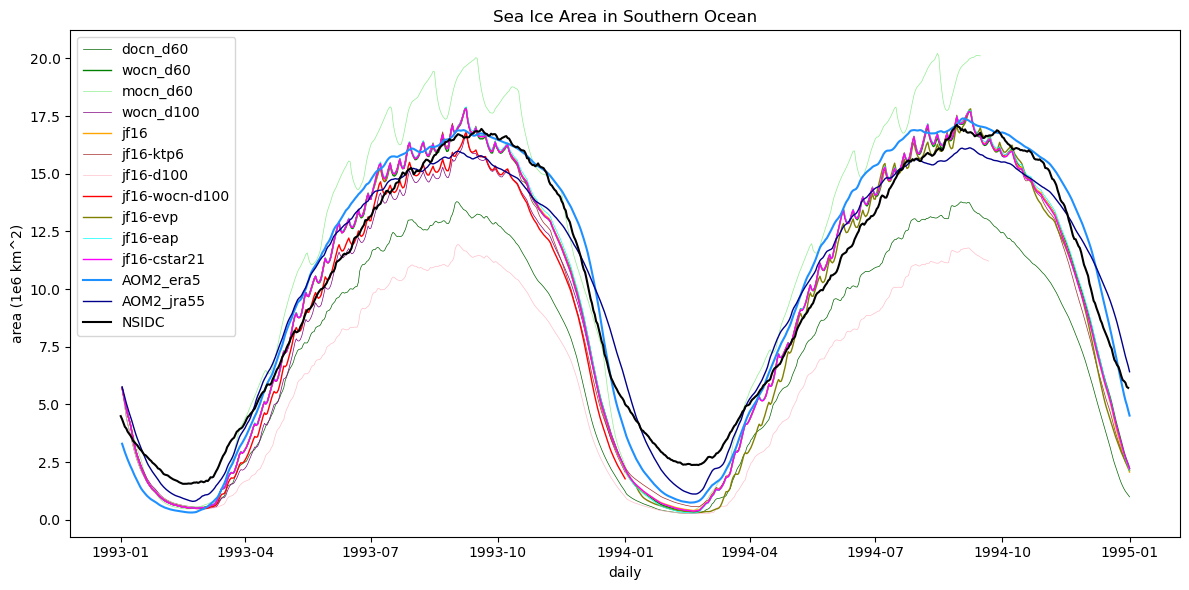

In [67]:
time = SIA['time'].values
data_vars = list(SIA.data_vars.keys())
var_name_clean = [ var_name.replace('AFIM_', '').replace('_SIA', '') if var_name.startswith('AFIM_') or var_name.endswith('_SIA') else var_name for var_name in data_vars]
plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
for i,var_name in enumerate(data_vars):
    # Remove the prefix "AFIM_" or the suffix "_SIA" if present
    sns.lineplot(x=time, y=SIA[var_name], label=var_name_clean[i], color=colors[var_name_clean[i]], linewidth=linewidths[var_name_clean[i]])#, marker=markers[var_name])
plt.xlabel('daily')
plt.ylabel('area (1e6 km^2)')
plt.title('Sea Ice Area in Southern Ocean')
plt.legend()
plt.tight_layout()
#plt.show()
plt.savefig(os.path.join(afim_anal.D_graphical,"timeseries","SIA_SH_1993-94.png"))

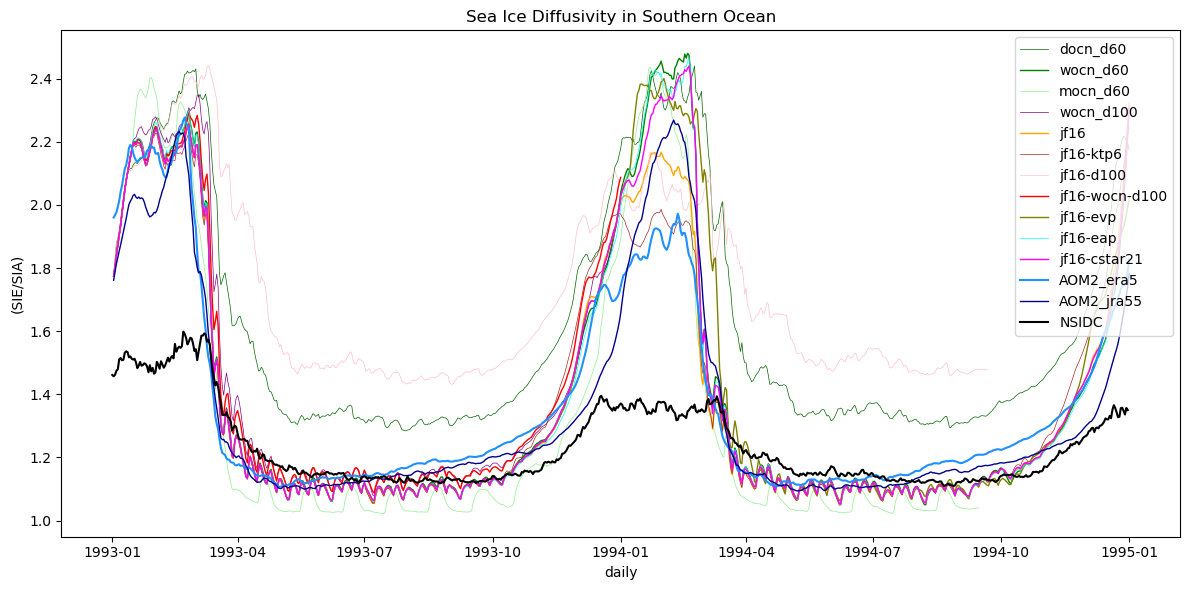

In [68]:
time = SIA['time'].values
sia_vars = list(SIA.data_vars.keys())
sie_vars = list(SIE.data_vars.keys())
var_name_clean = [ var_name.replace('AFIM_', '').replace('_SIA', '') if var_name.startswith('AFIM_') or var_name.endswith('_SIA') else var_name for var_name in data_vars]
plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
for i,sia_name in enumerate(sia_vars):
    sns.lineplot(x=time, y=SIE[sie_vars[i]]/SIA[sia_name], label=var_name_clean[i], color=colors[var_name_clean[i]], linewidth=linewidths[var_name_clean[i]])#, marker=markers[sia_name])
plt.xlabel('daily')
plt.ylabel('(SIE/SIA)')
plt.title('Sea Ice Diffusivity in Southern Ocean')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(afim_anal.D_graphical,"timeseries","SID_SH_1993-94.png"))
plt.show()

# STATIC ICE

In [37]:
STIC = {}
STIA = {}
STIE = {}
for run_name, run_config in afim_anal.AFIM_runs.items():
    P_stic = f"{afim_anal.D_tmp}/AFIM_{run_name}_stic.nc"
    P_stia = f"{afim_anal.D_tmp}/AFIM_{run_name}_stia.nc"
    P_stie = f"{afim_anal.D_tmp}/AFIM_{run_name}_stie.nc"
    if run_config['stic'] & run_config['anal']:
        print(f"computing STIC, STIA, STIE: {run_name}")
        STIC[run_name],STIA[run_name],STIE[run_name] = compute_static_ice( afim_ds[run_name] , stic=True, stia=True, stie=True, P_stic=P_stic, P_stia=P_stia, P_stie=P_stie)
    elif run_config['anal']:
        STIC[run_name] = xr.open_dataset(P_stic)
        STIA[run_name] = xr.open_dataset(P_stia)
        STIE[run_name] = xr.open_dataset(P_stie)

computing STIC, STIA, STIE: docn_d60
computing STIC, STIA, STIE: wocn_d60
computing STIC, STIA, STIE: mocn_d60
computing STIC, STIA, STIE: wocn_d100
computing STIC, STIA, STIE: jf16
computing STIC, STIA, STIE: jf16-ktp6
computing STIC, STIA, STIE: jf16-d100
computing STIC, STIA, STIE: jf16-wocn-d100
computing STIC, STIA, STIE: jf16-evp
computing STIC, STIA, STIE: jf16-eap
computing STIC, STIA, STIE: jf16-cstar21


In [46]:
P_stic = f"{afim_anal.D_tmp}/AOM2_era5_stic.nc"
P_stia = f"{afim_anal.D_tmp}/AOM2_era5_stia.nc"
P_stie = f"{afim_anal.D_tmp}/AOM2_era5_stie.nc"
AOM2_era5_STIC,AOM2_era5_STIA,AOM2_era5_STIE = compute_static_ice( aom2_era5, stic=True, stia=True, stie=True, P_stic=P_stic, P_stia=P_stia, P_stie=P_stie)
P_stic = f"{afim_anal.D_tmp}/AOM2_jra55_stic.nc"
P_stia = f"{afim_anal.D_tmp}/AOM2_jra55_stia.nc"
P_stie = f"{afim_anal.D_tmp}/AOM2_jra55_stie.nc"
AOM2_jra55_STIC,AOM2_jra55_STIA,AOM2_jra55_STIE = compute_static_ice( aom2_jra55, stic=True, stia=True, stie=True, P_stic=P_stic, P_stia=P_stia, P_stie=P_stie)

In [47]:
STIA   = None
STIE   = None
P_STIA = []
P_STIE = []
for run_name, run_config in afim_anal.AFIM_runs.items():
    if run_config['anal']:
        P_STIA.append(f"{afim_anal.D_tmp}/AFIM_{run_name}_stia.nc")
        P_STIE.append(f"{afim_anal.D_tmp}/AFIM_{run_name}_stie.nc")
P_STIA.append(f"{afim_anal.D_tmp}/AOM2_era5_stia.nc")
P_STIE.append(f"{afim_anal.D_tmp}/AOM2_era5_stie.nc") 
P_STIA.append(f"{afim_anal.D_tmp}/AOM2_jra55_stia.nc")
P_STIE.append(f"{afim_anal.D_tmp}/AOM2_jra55_stie.nc")
#STIA
datasets = []
variable_names = []
for fp in P_STIA:
    ds = xr.open_dataset(fp)
    var_name = list(ds.data_vars.keys())[0]  # Get the variable name
    ds = ds.rename({var_name: fp.split('/')[-1].split('.')[0]})  # Rename the variable to make it unique
    datasets.append(ds)
    variable_names.append(fp.split('/')[-1].split('.')[0])
STIA = xr.merge(datasets, join='outer')
STIA = STIA.fillna(np.nan)
STIA.to_netcdf("/g/data/jk72/da1339/tmp/STIA_1993-94.nc")
#STIE
datasets = []
variable_names = []
for fp in P_STIE:
    ds = xr.open_dataset(fp)
    var_name = list(ds.data_vars.keys())[0]  # Get the variable name
    ds = ds.rename({var_name: fp.split('/')[-1].split('.')[0]})  # Rename the variable to make it unique
    datasets.append(ds)
    variable_names.append(fp.split('/')[-1].split('.')[0])
STIE = xr.merge(datasets, join='outer')
STIE = STIE.fillna(np.nan)
STIE.to_netcdf("/g/data/jk72/da1339/tmp/STIE_1993-94.nc")

## Plotting

In [48]:
colors = {
    'docn_d60': 'darkgreen',
    'wocn_d60': 'green',
    'mocn_d60': 'lightgreen',
    'wocn_d100': 'purple',
    'jf16': 'orange',
    'jf16-ktp6': 'brown',
    'jf16-d100': 'pink',
    'jf16-wocn-d100': 'red',
    'jf16-evp': 'olive',
    'jf16-eap': 'cyan',
    'jf16-cstar21': 'magenta',
    'AOM2_era5': 'black',
    'AOM2_jra55': 'grey'
}
linewidths = {
    'docn_d60': 0.5,
    'wocn_d60': 1.,
    'mocn_d60': 0.5,
    'wocn_d100': 0.5,
    'jf16': 1.,
    'jf16-ktp6': 0.5,
    'jf16-d100': 0.5,
    'jf16-wocn-d100': 1.,
    'jf16-evp': 1.,
    'jf16-eap': 0.5,
    'jf16-cstar21': 1.,
    'AOM2_era5': 1.5,
    'AOM2_jra55': 1.
}
markers = {
    'docn_d60': 'o',
    'wocn_d60': 's',
    'mocn_d60': 'D',
    'wocn_d100': 'x',
    'jf16': '^',
    'jf16-ktp6': 'v',
    'jf16-d100': '>',
    'jf16-wocn-d100': '<',
    'jf16-evp': 'p',
    'jf16-eap': '*',
    'jf16-cstar21': 'h',
    'AOM2_era5': '+',
    'AOM2_jra55': '|',
}

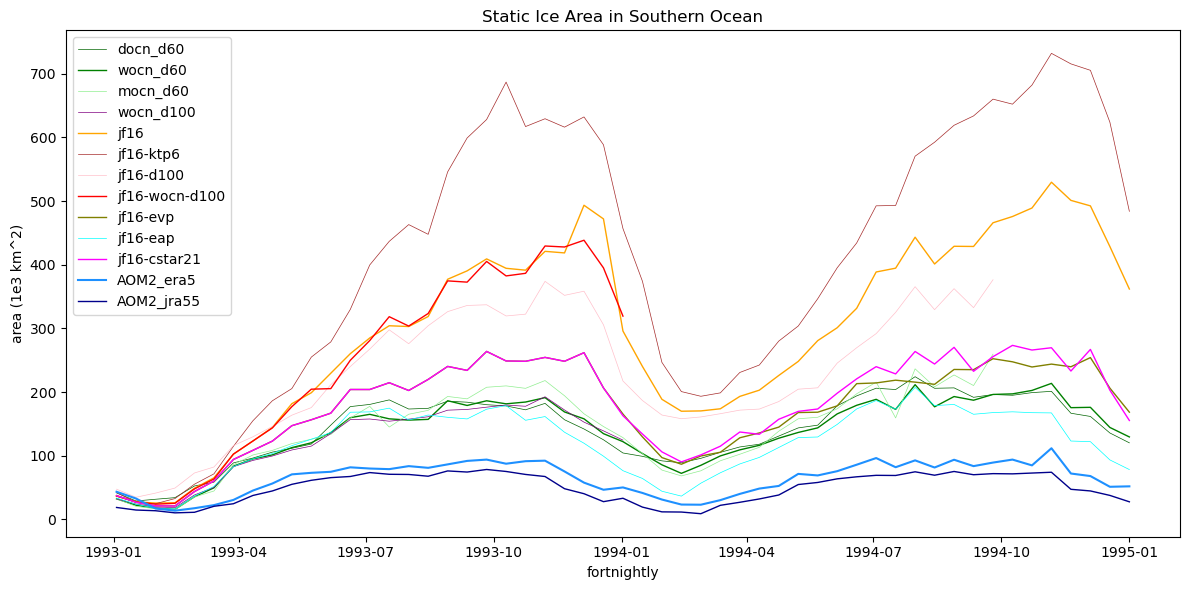

In [69]:
time = STIA['time'].values
data_vars = list(STIA.data_vars.keys())
plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
var_name_clean = [ var_name.replace('AFIM_', '').replace('_stia', '') if var_name.startswith('AFIM_') or var_name.endswith('_stia') else var_name for var_name in data_vars]
for i,var_name in enumerate(data_vars):
    # Remove the prefix "AFIM_" or the suffix "_STIA" if present
    sns.lineplot(x=time, y=STIA[var_name], label=var_name_clean[i], color=colors[var_name_clean[i]], linewidth=linewidths[var_name_clean[i]])#, marker=markers[var_name])
plt.xlabel('fortnightly')
plt.ylabel('area (1e3 km^2)')
plt.title('Static Ice Area in Southern Ocean')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(afim_anal.D_graphical,"timeseries","STIA_SH_1993-94.png"))
plt.show()

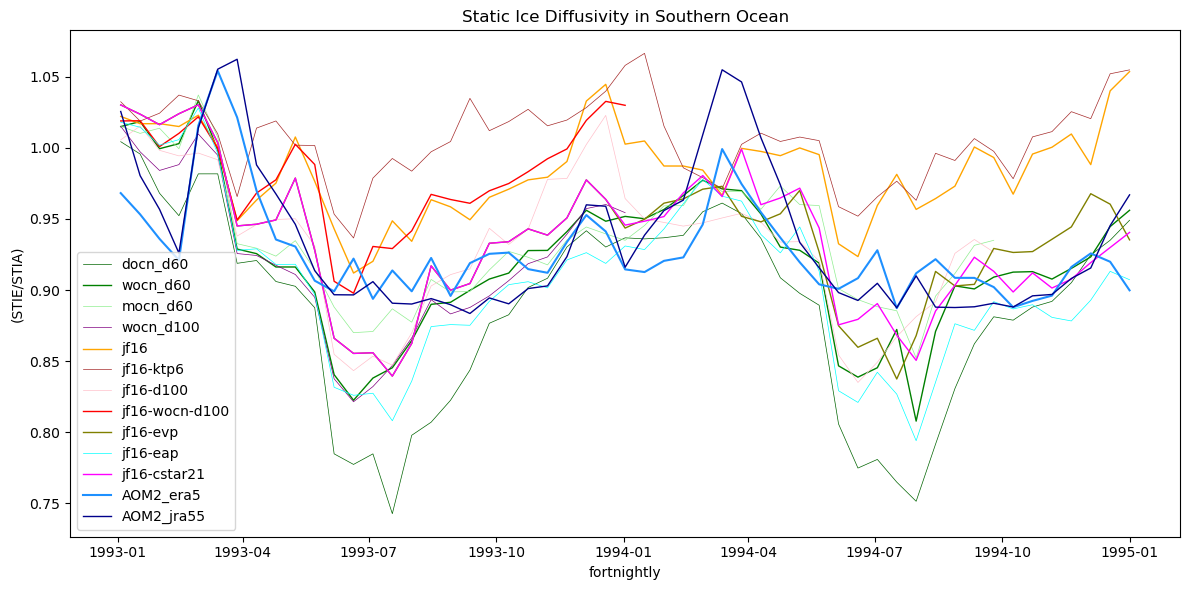

In [70]:
time = STIA['time'].values
stia_vars = list(STIA.data_vars.keys())
stie_vars = list(STIE.data_vars.keys())
var_name_clean = [ var_name.replace('AFIM_', '').replace('_stia', '') if var_name.startswith('AFIM_') or var_name.endswith('_stia') else var_name for var_name in data_vars]
plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
for i,stia_name in enumerate(stia_vars):
    sns.lineplot(x=time, y=STIE[stie_vars[i]]/STIA[stia_name]*1e8, label=var_name_clean[i], color=colors[var_name_clean[i]], linewidth=linewidths[var_name_clean[i]])#, marker=markers[sia_name])
plt.xlabel('fortnightly')
plt.ylabel('(STIE/STIA)')
plt.title('Static Ice Diffusivity in Southern Ocean')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(afim_anal.D_graphical,"timeseries","STID_SH_1993-94.png"))
plt.show()

# Sandbox

In [ ]:
for var_name in DS.data_vars:
    afim_anal.plot_basic_map( DS=DS, var_name=var_name, model_name='AFIM_wocn', model_forcing='ERA5', ice_or_ocean='ice' )

In [ ]:
# Define the threshold temperature
#sst_threshold = -1.5
def compute_area_below_threshold(data, tarea_data, threshold, lat_dim, lon_dim):
    """
    Compute the area where SST is below a specified threshold.

    Parameters:
    sst_data (xarray.DataArray): Sea surface temperature data.
    tarea_data (xarray.DataArray): Area data.
    threshold (float): SST threshold value.
    lat_dim (str): Latitude dimension name.
    lon_dim (str): Longitude dimension name.

    Returns:
    xarray.DataArray: Total area in million km² where SST is below the threshold.
    """
    # Apply mask where SST is below the threshold
    mask = data < threshold
    # Ensure no NaN values affect the calculation
    valid_tarea = tarea_data.where(mask & ~np.isnan(tarea_data))
    # Sum the area of cells where the mask is True
    area_below_threshold = valid_tarea.sum(dim=[lat_dim, lon_dim], skipna=True) / 1e12
    return area_below_threshold

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
AFIM_wocn_SIA.plot (ax=ax, label="AFIM_wocn",  color="blue",    linewidth=2)
AFIM_mocn_SIA.plot (ax=ax, label="AFIM_mocn",  color="green",   linewidth=1)
AFIM_jf16_SIA.plot (ax=ax, label="AFIM_jf16",  color="cyan",    linewidth=1)
AFIM_ktp6_SIA.plot (ax=ax, label="AFIM_ktp6",  color="magenta", linewidth=1)
AFIM_d100_SIA.plot (ax=ax, label="AFIM_d100",  color="yellow",  linewidth=1)
AOM2_era5_SIA.plot (ax=ax, label="AOM2_era5",  color="purple",  linewidth=2)
AOM2_jra55_SIA.plot(ax=ax, label="AOM2_jra55", color="black",   linewidth=1)
NSIDC_SIA.cell_area.plot(ax=ax, label="NSIDC",      color="orange",  linewidth=2)
ax.set_ylabel("Sea Ice Area (million km^2)")
ax.set_xlabel("Time")
ax.set_title("Antarctic Sea Ice Area Time Series Comparison")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(afim_anal.D_graphical,"cice-sa_dialy_SIA_1993_comparison.png"))  # Saving the plot
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
afim_anal.docn_d60_SIE.plot       (ax=ax, label="Docn_MLD60",        color="blue",    linewidth=2)
afim_anal.wocn_d60_SIE.plot       (ax=ax, label="Wocn_MLD60",        color="green",   linewidth=2, marker='x')
afim_anal.mocn_d60_SIE.plot       (ax=ax, label="Mocn_MLD60",        color="cyan",    linewidth=2, marker='x')
afim_anal.wocn_d20_SIE.plot       (ax=ax, label="Wocn_MLD20",        color="magenta", linewidth=2)
afim_anal.wocn_d100_SIE.plot      (ax=ax, label="Wocn_MLD100",       color="purple",  linewidth=2)
afim_anal.wocn_d100_dt900_SIE.plot(ax=ax, label="Wocn_MLD100_dt900", color="black",   linewidth=2)
afim_anal.AOM2_SIE.plot           (ax=ax, label="ACCESS-OM2",        color="orange",  linewidth=2, marker='x')
afim_anal.NSIDC_SIE.plot          (ax=ax, label='NSIDC (G02202_V4)', color='red',     linewidth=2, marker='x')
ax.set_ylabel("Sea Ice Area (million km^2)")
ax.set_xlabel("Time")
ax.set_title("Antarctic Sea Ice Extent Time Series Comparison")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(afim_anal.D_graphical,"cice-sa_202404_RUNS_vs_nsdic_SH_monthly_SIE_1993-1998.png"))  # Saving the plot
plt.show()

In [ ]:
AFIM_wocn_uvel_SH  = afim_anal.mask_hemisphere(AFIM_wocn, var_name='uvel', grid_type='u')
AFIM_wocn_vvel_SH  = afim_anal.mask_hemisphere(AFIM_wocn, var_name='vvel', grid_type='u')
AFIM_mocn_uvel_SH  = afim_anal.mask_hemisphere(AFIM_mocn, var_name='uvel', grid_type='u')
AFIM_mocn_vvel_SH  = afim_anal.mask_hemisphere(AFIM_mocn, var_name='vvel', grid_type='u')
AFIM_docn_uvel_SH  = afim_anal.mask_hemisphere(AFIM_docn, var_name='uvel', grid_type='u')
AFIM_docn_vvel_SH  = afim_anal.mask_hemisphere(AFIM_docn, var_name='vvel', grid_type='u')
AFIM_jf16_uvel_SH  = afim_anal.mask_hemisphere(AFIM_jf16, var_name='uvel', grid_type='u')
AFIM_jf16_vvel_SH  = afim_anal.mask_hemisphere(AFIM_jf16, var_name='vvel', grid_type='u')
AFIM_ktp6_uvel_SH  = afim_anal.mask_hemisphere(AFIM_ktp6, var_name='uvel', grid_type='u')
AFIM_ktp6_vvel_SH  = afim_anal.mask_hemisphere(AFIM_ktp6, var_name='vvel', grid_type='u')
AFIM_d100_uvel_SH  = afim_anal.mask_hemisphere(AFIM_d100, var_name='uvel', grid_type='u')
AFIM_d100_vvel_SH  = afim_anal.mask_hemisphere(AFIM_d100, var_name='vvel', grid_type='u')
AFIM_evp_uvel_SH  = afim_anal.mask_hemisphere(AFIM_evp, var_name='uvel', grid_type='u')
AFIM_evp_vvel_SH  = afim_anal.mask_hemisphere(AFIM_evp, var_name='vvel', grid_type='u')
AFIM_wd100_uvel_SH  = afim_anal.mask_hemisphere(AFIM_wd100, var_name='uvel', grid_type='u')
AFIM_wd100_vvel_SH  = afim_anal.mask_hemisphere(AFIM_wd100, var_name='vvel', grid_type='u')
AOM2_era5_uvel_SH  = afim_anal.mask_hemisphere(AOM2_ERA5_ice, var_name='uvel', grid_type='u')
AOM2_era5_vvel_SH  = afim_anal.mask_hemisphere(AOM2_ERA5_ice, var_name='vvel', grid_type='u')
AOM2_jra55_uvel_SH = afim_anal.mask_hemisphere(AOM2_JRA55_ice, var_name='uvel', grid_type='u')
AOM2_jra55_vvel_SH = afim_anal.mask_hemisphere(AOM2_JRA55_ice, var_name='vvel', grid_type='u')
AFIM_wocn_uvel_SH  = AFIM_wocn_uvel_SH.sortby('time')
AFIM_wocn_vvel_SH  = AFIM_wocn_vvel_SH.sortby('time')
AFIM_mocn_uvel_SH  = AFIM_mocn_uvel_SH.sortby('time')
AFIM_mocn_vvel_SH  = AFIM_mocn_vvel_SH.sortby('time')
AFIM_docn_uvel_SH  = AFIM_docn_uvel_SH.sortby('time')
AFIM_docn_vvel_SH  = AFIM_docn_vvel_SH.sortby('time')
AFIM_jf16_uvel_SH  = AFIM_jf16_uvel_SH.sortby('time')
AFIM_jf16_vvel_SH  = AFIM_jf16_vvel_SH.sortby('time')
AFIM_ktp6_uvel_SH  = AFIM_ktp6_uvel_SH.sortby('time')
AFIM_ktp6_vvel_SH  = AFIM_ktp6_vvel_SH.sortby('time')
AFIM_d100_uvel_SH  = AFIM_d100_uvel_SH.sortby('time')
AFIM_d100_vvel_SH  = AFIM_d100_vvel_SH.sortby('time')
AFIM_evp_uvel_SH  = AFIM_evp_uvel_SH.sortby('time')
AFIM_evp_vvel_SH  = AFIM_evp_vvel_SH.sortby('time')
AFIM_wd100_uvel_SH  = AFIM_wd100_uvel_SH.sortby('time')
AFIM_wd100_vvel_SH  = AFIM_wd100_vvel_SH.sortby('time')
AOM2_era5_uvel_SH  = AOM2_era5_uvel_SH.sortby('time')
AOM2_era5_vvel_SH  = AOM2_era5_vvel_SH.sortby('time')
AOM2_jra55_uvel_SH = AOM2_jra55_uvel_SH.sortby('time')
AOM2_jra55_vvel_SH = AOM2_jra55_vvel_SH.sortby('time')

In [ ]:
AFIM_wocn_uarea_SH      = afim_anal.mask_hemisphere(AFIM_wocn, var_name='uarea', grid_type='u')
#AFIM_wocn_uarea_SH      = AFIM_wocn_uarea_SH.sortby('time')
#AFIM_wocn_uarea_SH_ftnt = AFIM_wocn_uarea_SH.resample(time='2W').mean()
AFIM_wocn_aice_SH       = AFIM_wocn_aice_SH.sortby('time')
AFIM_wocn_aice_SH_ftnt  = AFIM_wocn_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_wocn_uvel_SH**2 + AFIM_wocn_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_wocn_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_wocn_FI_SH         = AFIM_wocn_aice_SH.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
print(AFIM_wocn_FI_SH)

In [ ]:
AFIM_wocn_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_wocn_FI_SH_1993-94.nc")

In [ ]:
AFIM_mocn_uarea_SH      = afim_anal.mask_hemisphere(AFIM_mocn, var_name='uarea', grid_type='u')
#AFIM_mocn_uarea_SH      = AFIM_mocn_uarea_SH.sortby('time')
#AFIM_mocn_uarea_SH_ftnt = AFIM_mocn_uarea_SH.resample(time='2W').mean()
AFIM_mocn_aice_SH       = AFIM_mocn_aice_SH.sortby('time')
AFIM_mocn_aice_SH_ftnt  = AFIM_mocn_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_mocn_uvel_SH**2 + AFIM_mocn_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_mocn_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_mocn_FI_SH         = AFIM_mocn_aice_SH.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AFIM_mocn_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_mocn_FI_SH_1993-94.nc")

In [ ]:
AFIM_docn_uarea_SH      = afim_anal.mask_hemisphere(AFIM_docn, var_name='uarea', grid_type='u')
#AFIM_docn_uarea_SH      = AFIM_docn_uarea_SH.sortby('time')
#AFIM_docn_uarea_SH_ftnt = AFIM_docn_uarea_SH.resample(time='2W').mean()
AFIM_docn_aice_SH       = AFIM_docn_aice_SH.sortby('time')
AFIM_docn_aice_SH_ftnt  = AFIM_docn_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_docn_uvel_SH**2 + AFIM_docn_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_docn_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_docn_FI_SH         = AFIM_docn_aice_SH.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AFIM_docn_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_docn_FI_SH_1993-94.nc")

In [ ]:
AFIM_jf16_uarea_SH      = afim_anal.mask_hemisphere(AFIM_jf16, var_name='uarea', grid_type='u')
#AFIM_jf16_uarea_SH      = AFIM_jf16_uarea_SH.sortby('time')
#AFIM_jf16_uarea_SH_ftnt = AFIM_jf16_uarea_SH.resample(time='2W').mean()
AFIM_jf16_aice_SH       = AFIM_jf16_aice_SH.sortby('time')
AFIM_jf16_aice_SH_ftnt  = AFIM_jf16_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_jf16_uvel_SH**2 + AFIM_jf16_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_jf16_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_jf16_FI_SH         = AFIM_jf16_aice_SH.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AFIM_jf16_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_jf16_FI_SH_1993-94.nc")

In [ ]:
AFIM_ktp6_uarea_SH      = afim_anal.mask_hemisphere(AFIM_ktp6, var_name='uarea', grid_type='u')
#AFIM_ktp6_uarea_SH      = AFIM_ktp6_uarea_SH.sortby('time')
#AFIM_ktp6_uarea_SH_ftnt = AFIM_ktp6_uarea_SH.resample(time='2W').mean()
AFIM_ktp6_aice_SH       = AFIM_ktp6_aice_SH.sortby('time')
AFIM_ktp6_aice_SH_ftnt  = AFIM_ktp6_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_ktp6_uvel_SH**2 + AFIM_ktp6_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_ktp6_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_ktp6_FI_SH         = AFIM_ktp6_aice_SH.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AFIM_ktp6_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_ktp6_FI_SH_1993-94.nc")

In [ ]:
AFIM_d100_uarea_SH      = afim_anal.mask_hemisphere(AFIM_d100, var_name='uarea', grid_type='u')
#AFIM_d100_uarea_SH      = AFIM_d100_uarea_SH.sortby('time')
#AFIM_d100_uarea_SH_ftnt = AFIM_d100_uarea_SH.resample(time='2W').mean()
AFIM_d100_aice_SH       = AFIM_d100_aice_SH.sortby('time')
AFIM_d100_aice_SH_ftnt  = AFIM_d100_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_d100_uvel_SH**2 + AFIM_d100_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_d100_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_d100_FI_SH         = AFIM_d100_aice_SH.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AFIM_d100_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_d100_FI_SH_1993-94.nc")

In [ ]:
AFIM_evp_uarea_SH      = afim_anal.mask_hemisphere(AFIM_evp, var_name='uarea', grid_type='u')
#AFIM_evp_uarea_SH      = AFIM_evp_uarea_SH.sortby('time')
#AFIM_evp_uarea_SH_ftnt = AFIM_evp_uarea_SH.resample(time='2W').mean()
AFIM_evp_aice_SH       = AFIM_evp_aice_SH.sortby('time')
AFIM_evp_aice_SH_ftnt  = AFIM_evp_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AFIM_evp_uvel_SH**2 + AFIM_evp_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AFIM_evp_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AFIM_evp_FI_SH         = AFIM_evp_aice_SH.where(fast_ice_condition).sum(dim=['nj', 'ni'])/1e9
#AFIM_evp_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_evp_FI_SH_1993-94.nc")
AFIM_evp_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_evp_FI_timeseries.nc")

In [ ]:
AOM2_era5_uarea_SH      = afim_anal.mask_hemisphere(AOM2_ERA5_ice, var_name='uarea', grid_type='u')
AOM2_era5_uarea_SH      = AOM2_era5_uarea_SH.sortby('time')
AOM2_era5_uarea_SH_ftnt = AOM2_era5_uarea_SH.resample(time='2W').mean()
AOM2_era5_aice_SH       = AOM2_era5_aice_SH.sortby('time')
AOM2_era5_aice_SH_ftnt  = AOM2_era5_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AOM2_era5_uvel_SH**2 + AOM2_era5_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AOM2_era5_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AOM2_era5_FI_SH         = AOM2_era5_aice_SH_ftnt.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AOM2_era5_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AOM2_era5_FI_SH_1993-94.nc")

In [ ]:
AOM2_jra55_uarea_SH      = afim_anal.mask_hemisphere(AOM2_JRA55_ice, var_name='uarea', grid_type='u')
AOM2_jra55_uarea_SH      = AOM2_jra55_uarea_SH.sortby('time')
AOM2_jra55_uarea_SH_ftnt = AOM2_jra55_uarea_SH.resample(time='2W').mean()
AOM2_jra55_aice_SH       = AOM2_jra55_aice_SH.sortby('time')
AOM2_jra55_aice_SH_ftnt  = AOM2_jra55_aice_SH.resample(time='2W').mean()
ispd                    = np.sqrt(AOM2_jra55_uvel_SH**2 + AOM2_jra55_vvel_SH**2)
ispd_ftnt               = ispd.resample(time='2W').mean()
aice_condition          = AOM2_jra55_aice_SH_ftnt > afim_anal.aice_thresh
ispd_condition          = ispd_ftnt < afim_anal.FI_thresh
fast_ice_condition      = aice_condition & ispd_condition
AOM2_jra55_FI_SH         = AOM2_jra55_aice_SH_ftnt.where(fast_ice_condition)#.sum(dim=['nj', 'ni'])/1e9
AOM2_jra55_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AOM2_jra55_FI_SH_1993-94.nc")

In [ ]:
name1 = 'AOM2_era5'
name2 = 'AFIM_d100'
da1  = eval(f"{name1}_FI_SH")
da2  = eval(f"{name2}_FI_SH")
t    = pd.DatetimeIndex(da1.time.values) - pd.DateOffset(days=1)
D_save = f"/g/data/jk72/da1339/GRAPHICAL/static_ice_maps/{name1}"
#D_save = f"/g/data/jk72/da1339/GRAPHICAL/static_ice_maps/dif_maps/{name1}_minus_{name2}"
if not os.path.exists(D_save): os.makedirs(D_save)
for i in range(len(t)):
    fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-75,-60], ccrs.PlateCarree())
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    t_str = t[i].strftime('%Y-%m-%d')
    pcm = ax.pcolormesh(da1.ULON, da1.ULAT, da1.isel(time=i), cmap=cm.cm.amp, vmin=0, vmax=1, transform=ccrs.PlateCarree())
    #pcm = ax.pcolormesh(da1.ULON, da1.ULAT, ( da1.isel(time=i)-da2.isel(time=i) ), cmap=cm.cm.balance, vmin=-1, vmax=1, transform=ccrs.PlateCarree())
    ax.add_feature(cft.LAND, color='darkgrey')
    ax.add_feature(cft.COASTLINE, linewidth=.5)
    plt.colorbar(pcm, label='concentration', shrink=0.9)
    plt.title(f'{t_str}')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    F_save = f"{t_str}_{name1}_SH.png"
    #F_save = f"{t_str}_{name1}_minus_{name2}_SH.png"
    P_save = os.path.join(D_save,F_save)
    plt.savefig(P_save)
    #plt.show()
    print(f"saved: {P_save}")
    plt.close()

In [ ]:
AOM2_era5_FI_SH.isel(time=20).plot()

In [ ]:
# AFIM_wocn_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_wocn_FI.nc")
# AFIM_mocn_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_mocn_FI.nc")
AFIM_docn_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_docn_FI.nc")
# AFIM_jf16_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_jf16_FI.nc")
# AFIM_ktp6_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_ktp6_FI.nc")
# AFIM_d100_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AFIM_d100_FI.nc")
# AOM2_era5_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AOM2_era5_FI.nc")
# AOM2_jra55_FI_SH.to_netcdf("/g/data/jk72/da1339/tmp/AOM2_jra55_FI.nc")

In [ ]:
file_paths = [
    "/home/581/da1339/data_jk72/tmp/AFIM_d100_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AFIM_jf16_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AFIM_ktp6_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AFIM_mocn_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AFIM_wocn_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AFIM_docn_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AOM2_era5_FI.nc",
    "/home/581/da1339/data_jk72/tmp/AOM2_jra55_FI.nc"
]
datasets = []
variable_names = []
for fp in file_paths:
    ds = xr.open_dataset(fp)
    var_name = list(ds.data_vars.keys())[0]  # Get the variable name
    ds = ds.rename({var_name: fp.split('/')[-1].split('.')[0]})  # Rename the variable to make it unique
    datasets.append(ds)
    variable_names.append(fp.split('/')[-1].split('.')[0])
combined = xr.merge(datasets, join='outer')
combined = combined.fillna(np.nan)
combined.to_netcdf("/g/data/jk72/da1339/tmp/FIA_1993-94.nc")

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(AFIM_wocn_FI_SH.time.values, AFIM_wocn_FI_SH.values, label='AFIM_wocn', color='royalblue')#, marker='o')
plt.plot(AFIM_mocn_FI_SH.time.values, AFIM_mocn_FI_SH.values, label='AFIM_mocn', color='cyan')#, marker='o')
#plt.plot(AFIM_docn_FI_SH.time.values, AFIM_docn_FI_SH.values, label='AFIM_docn', color='skyblue')#, marker='o')
plt.plot(AFIM_jf16_FI_SH.time.values, AFIM_jf16_FI_SH.values, label='AFIM_jf16', color='green')#, marker='o')
plt.plot(AFIM_ktp6_FI_SH.time.values, AFIM_ktp6_FI_SH.values, label='AFIM_ktp6', color='lawngreen')#, marker='o')
plt.plot(AFIM_d100_FI_SH.time.values, AFIM_d100_FI_SH.values, label='AFIM_d100', color='mediumspringgreen')#, marker='o')
plt.plot(AOM2_era5_FI_SH.time.values, AOM2_era5_FI_SH.values, label='AOM2_era5', color='red')#, marker='x')
plt.plot(AOM2_jra55_FI_SH.time.values, AOM2_jra55_FI_SH.values, label='AOM2_jra55', color='brown')#, marker='x')
#plt.xlabel('time')
plt.ylabel('area (1000 km^2)')
plt.title('Time-series of Antarctic fast ice area')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(afim_anal.D_graphical,"timeseries","AOM2_and_AFIM_fi_area_SH_1993.png"))
plt.show()

In [ ]:
ERA5 = xr.open_dataset("/g/data/jk72/da1339/afim_input/ERA5/0p25/era5_for_cice6_1993.nc")
ERA5_u_SH = ERA5.wndewd.isel(ny=slice(0,540))
ERA5_v_SH = ERA5.wndnwd.isel(ny=slice(0,540))

In [ ]:
ispd      = np.sqrt(ERA5_u_SH**2 + ERA5_v_SH**2)
ispd_ftnt = ispd.resample(time='2W').mean()
ispd_ftnt

In [ ]:
#AOM2_ERA5_ocn = afim_anal.load_dataset(DS_name='AOM2', data_type='ocean', proc_freq='daily', frcg_type='era5')
AOM2_JRA55_ocn = afim_anal.load_dataset(DS_name='AOM2', data_type='ocean', proc_freq='daily', frcg_type='era5')
AOM2_JRA55_ocn

In [ ]:
DS = mpc.wind_speed( AOM2_JRA55_ice['uvel'] , AOM2_JRA55_ice['vvel'] )
AOM2_JRA55_ice

In [ ]:
AOM2_ERA5_ice

In [ ]:
var_name = 'uvel'
#DS = AOM2_JRA55_ice[var_name]
da = DS.isel(time=15)
t_str = da.time.values.astype('datetime64[D]').astype(str)
tit_str = f"AOM2_JRA55 {var_name} {t_str}"
D_save = os.path.join("/g/data/jk72/da1339/GRAPHICAL","AOM2","JRA55","ice",var_name)
F_save = f"{t_str}_AOM2_JRA55_{var_name}_SH.png"
vmin = 0
vmax = 1
cmap = cm.cm.speed
grid_type = 'u'
plot_basic_map( da=da, grid_type=grid_type, vmin=vmin, vmax=vmax, cmap=cmap, title=tit_str, D_save=D_save, F_save=F_save, cbar_label='m/s')

In [ ]:
da = 
ln = AOM2_ERA5_ocn.xt_ocean
lt = AOM2_ERA5_ocn.yt_ocean
t_str = da.time.values.astype('datetime64[D]').astype(str)
fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)
pcm = ax.pcolormesh(ln, lt, da, cmap=cm.cm.haline, vmin=30, vmax=37, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=.5)
plt.colorbar(pcm, label='psu', shrink=0.9)
plt.title(f'AOM2_ERA5 SSS {t_str}')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
plt.savefig(os.path.join("/g/data/jk72/da1339/GRAPHICAL","AOM2","ERA5","ocn","sss",f"{t_str}_AOM2_ERA5_SSS_SH.png"))
plt.show()
plt.close()

In [ ]:
#ERA5     = xr.open_dataset("/g/data/jk72/da1339/afim_input/ERA5/0p25/era5_for_cice6_1993.nc")
ERA5         = xr.open_dataset("/g/data/jk72/da1339/afim_input/ERA5/0p25/era5_for_cice6_1998.nc")
ERA5_98sep   = ERA5.sel(time=slice("1998-09-01","1998-09-30"))
ERA5_d_98sep = ERA5_98sep.resample(time='1D').mean()
ERA5_d_98sep['wndspd'] = np.sqrt( ERA5_d_98sep.wndewd**2 + ERA5_d_98sep.wndnwd**2 )
ERA5_d_98sep.to_netcdf("/g/data/jk72/da1339/atm/ERA5/era5_daily_1998-09.nc")

In [ ]:
FI_AFIM_aice = AFIM_d.isel(time=0).aice.values[FI_AFIM.isel(time=0)]
FI_AOM2_aice = AOM2_d.isel(time=0).aice.values[FI_AOM2.isel(time=0)]
print(np.shape(FI_AFIM_aice))
print(np.shape(FI_AOM2_aice))

In [ ]:
#dif          = FI_AOM2_aice - FI_AFIM_aice
fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
ax.set_extent([0,360,-90,-55], ccrs.PlateCarree())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)
pcm = ax.pcolormesh(FI_AFIM_98sep.TLON.values[FI_AFIM_98sep.isel(time=0)],
                    FI_AFIM_98sep.TLAT.values[FI_AFIM_98sep.isel(time=0)],
                    FI_AFIM_aice, cmap=cm.cm.amp, vmin=0, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=.5)
plt.colorbar(pcm, label='m/s', shrink=0.9)
t_str = FI_AFIM_98sep.time.isel(time=0).values.astype('datetime64[M]').astype(str)
plt.title(f'Fast Ice Pixels CICE-SA {t_str}')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
#plt.savefig(os.path.join(D_save,f"{t_str}_FI_SH.png"))
plt.show()
plt.close()
fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
ax.set_extent([0,360,-90,-55], ccrs.PlateCarree())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)
pcm = ax.pcolormesh(FI_AOM2_98sep.TLON, FI_AOM2_98sep.TLAT, FI_AOM2_aice, cmap=cm.cm.amp, vmin=0, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=.5)
plt.colorbar(pcm, label='m/s', shrink=0.9)
t_str = FI_AOM2_98sep.time.isel(time=0).values.astype('datetime64[M]').astype(str)
plt.title(f'Fast Ice Pixels ACCESS-OM2 {t_str}')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
#plt.savefig(os.path.join(D_save,f"{t_str}_FI_SH.png"))
plt.show()
plt.close()

In [ ]:
from scipy.ndimage import distance_transform_edt
land_mask = AFIM_d_sep['tmask'].values  # Example: 1 for land, 0 for ocean
# distance_to_land = distance_transform_edt(land_mask == 0)
# coastal_mask = distance_to_land <= 50  # Example: within 50 grid cells from land
# # Apply the coastal mask to your variables
ERA5_d_sep.airtmp.isel(time=15).drop_vars('time')#.where(land_mask)
#SIC = AFIM_d_sep.aice.isel(time=15).where(land_mask).drop('time')
#SIT = AFIM_d_sep.hi.isel(time=15).where(land_mask).drop('time')
# Convert to pandas DataFrame for easier analysis
#data = xr.Dataset({'T2M' : T2M,
#                   'SIC' : SIC,
#                   'SIT' : SIT}).to_dataframe().dropna()

In [ ]:
D_save = "/g/data/jk72/da1339/GRAPHICAL/ERA5/wind_speed/"
if not os.path.exists(D_save): os.makedirs(D_save)
for i in range(len(wndspd_m.time)):
    fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-90,-55], ccrs.PlateCarree())
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    pcm = ax.pcolormesh(ERA5.LON, ERA5.LAT, wndspd_m.isel(time=i), cmap=cm.cm.amp, vmin=0, vmax=20, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    plt.colorbar(pcm, label='m/s', shrink=0.9)
    t_str = wndspd_m.time.isel(time=i).values.astype('datetime64[M]').astype(str)
    plt.title(f'Wind Speed Monthly Mean {t_str}')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    plt.savefig(os.path.join(D_save,f"{t_str}_wndspd_SH.png"))
    plt.show()
    plt.close()

In [ ]:
AFIM = AFIM_d
AOM2 = AOM2_d
t = pd.DatetimeIndex(AFIM.time.values) - pd.DateOffset(days=1)
D_save = "/g/data/jk72/da1339/GRAPHICAL/CICE/dif_maps/aice_AOM2_minus_AFIM_SH/"
if not os.path.exists(D_save): os.makedirs(D_save)
for i in range(len(t)):
    fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    t_str = t[i].strftime('%Y-%m-%d')
    aom2  = AOM2_d_98sep.aice.isel(time=i)
    afim  = AFIM_d_98sep.aice.isel(time=i)
    aice  = aom2 - afim
    pcm = ax.pcolormesh(AFIM_d_98sep.TLON, AFIM_d_98sep.TLAT, aice, cmap=cm.cm.balance, vmin=-1, vmax=1, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    plt.colorbar(pcm, label='Sea Ice Concentration difference', shrink=0.9)
    plt.title(f'Sea Ice Concentration Difference (ACCESS-OM2 - CICE-SA) at Time {t_str}')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    F_save = f"{t_str}_aice_diff_AOM2_AFIM_SH.png"
    P_save = os.path.join(D_save,F_save)
    plt.savefig(P_save)
    plt.show()
    plt.close()

In [ ]:
# Define paths
D_save = "/g/data/jk72/da1339/GRAPHICAL/CICE/dif_maps/aice_AOM2_minus_AFIM_SH/"
if not os.path.exists(D_save): os.makedirs(D_save)
nsidc_conc = afim_anal.NSIDC['cdr_seaice_conc_monthly']
# Iterate over time steps
for i in range(len(afim_anal.wocn_d60.time)):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0, 360, -90, -50], ccrs.PlateCarree())
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    t_str = afim_anal.wocn_d60.time.isel(time=i).values.astype('datetime64[M]').astype(str)
    aom2 = afim_anal.AOM2.aice_m.isel(time=i)
    afim = afim_anal.wocn_d60.aice_m.isel(time=i)
    aice = aom2 - afim
    pcm = ax.pcolormesh(afim.TLON, afim.TLAT, aice, cmap=cm.cm.balance, vmin=-1, vmax=1, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    plt.colorbar(pcm, label='Sea Ice Concentration difference', shrink=0.9)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    nsidc_extent = nsidc_conc.isel(time=i) > afim_anal.aice_thresh
    nsidc_extent = nsidc_extent.where(nsidc_extent, np.nan)  # Mask to get NaNs for non-extent areas
    ax.contour(afim_anal.NSIDC.xgrid, afim_anal.NSIDC.ygrid, nsidc_extent, colors='orange', linewidths=5, transform=ccrs.PlateCarree())#transform=ccrs.Stereographic(central_longitude=0, central_latitude=-90))
    plt.title(f'Sea Ice Concentration Difference (ACCESS-OM2 - CICE-SA) at Time {t_str}')
    F_save = f"{t_str}_aice_diff_AOM2_AFIM_SH.png"
    P_save = os.path.join(D_save, F_save)
    #plt.savefig(P_save)
    plt.show()
    plt.close()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)
t_str = I_025_afim.time.isel(time=0).values.astype('datetime64[M]').astype(str)
aom2  = I_025_aom2.aice_m.isel(time=0)
afim  = I_025_afim.aice_m.isel(time=0)
aice  = aom2 - afim
pcm = ax.pcolormesh(afim.TLON, afim.TLAT, aice, cmap=cm.cm.balance, vmin=-1, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=.5)
plt.colorbar(pcm, label='Sea Ice Concentration difference', shrink=0.9)
plt.title(f'Sea Ice Concentration Difference (ACCESS-OM2 - CICE-SA) at Time {t_str}')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
#gl.xformatter = plt.FuncFormatter(lambda x, _: f"{x:.2f}°E" if x > 0 else f"{-x:.2f}°W")
#gl.yformatter = plt.FuncFormatter(lambda y, _: f"{-y:.2f}°S" if y < 0 else f"{y:.2f}°N")
#file_name = f"{t_str}_aice_diffs_NSIDC_CICE_bathy_SH.png"
#save_path = os.path.join(save_dir, file_name)
#plt.savefig(save_path)
plt.show()

In [ ]:
cice_thick  = afim_anal.wk_multyr_HEM.hi_m.sum(dim=('nj','ni'))
#cice_tarea = afim_anal.wk_multyr_HEM.tarea
#cice_vol   = (cice_hi_m * cice_tarea).sum(dim=('nj','ni'))
aom2_thick  = afim_anal.AOM2_HEM.hi_m.sum(dim=('nj','ni'))
#aom2_tarea = afim_anal.AOM2_HEM.tarea
#aom2_vol   = (aom2_hi_m * aom2_tarea).sum(dim=('nj','ni'))
fig, ax    = plt.subplots(figsize=(12, 6))
cice_thick.plot(ax=ax, label="CICE-SA", color="blue", linewidth=2, marker='o')
aom2_thick.plot(ax=ax, label="ACCESS-OM2", color="black", linewidth=2, marker='*')
ax.set_ylabel("summed thickness (m)")
ax.set_xlabel("Time")
ax.set_title("Antarctic Sea Ice Thickness (dimensional sum) Time-Series Comparison")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(afim_anal.D_graphical,"cice-sa_202404_RUNS_vs_nsdic_SH_monthly_THICK_1993-1998.png"))  # Saving the plot
plt.show()

In [ ]:
wks                        = Ngl.open_wks("png",os.path.join(afim_anal.D_graphical,"test"))
res                        = Ngl.Resources()
res.nglFrame               = False
res.lbOrientation          = "horizontal"
res.sfXArray               = afim_anal.AOM2.TLON[:,0].values
res.sfYArray               = afim_anal.AOM2.TLAT[0,:].values
res.mpFillOn               = True
res.mpOceanFillColor       = "Transparent"
res.mpLandFillColor        = "Gray90"
res.mpInlandWaterFillColor = "Gray90"
plot                       = Ngl.contour_map(wks,afim_anal.AOM2["aice_m"][10,:,:].values,res)
txres                      = Ngl.Resources()
txres.txFontHeightF        = 0.014
Ngl.text_ndc(wks,'AICE',0.14,0.78,txres)
Ngl.text_ndc(wks,'%',0.95,0.78,txres)
Ngl.frame(wks)
Ngl.end()

In [ ]:
#must use ncrcat to concatenate files first
NSIDC = xr.open_dataset("/g/data/jk72/da1339/SeaIce/nsidc/G02202_V4/seaice_conc_monthly_sh_2005-2009.nc")
NSIDC = NSIDC.isel(tdim=slice(0,35))
#print(NSIDC)
#print(NSIDC.projection.attrs)
src_crs = pyproj.CRS("+proj=stere +lat_0=-90 +lat_ts=-70 +lon_0=0 +k=1 +x_0=0 +y_0=0 +a=6378273 +b=6356889.449 +units=m +no_defs")
tgt_crs = pyproj.CRS("+proj=latlon")
xfmr = pyproj.Transformer.from_crs(src_crs, tgt_crs)
X,Y = np.meshgrid(NSIDC.xgrid.values, NSIDC.ygrid.values)
NSIDC_LON,NSIDC_LAT = xfmr.transform(X,Y)
#NSIDC.time.isel(tdim=0).values.astype('datetime64[M]').astype(str)
ds_src    = xr.Dataset(coords = {'longitude': (('nj', 'ni'), NSIDC_LON), 'latitude': (('nj', 'ni'), NSIDC_LAT)                    })
ds_tgt    = xr.Dataset(coords = {'longitude': (('nj','ni'), cice['TLON'].values), 'latitude': (('nj','ni'), cice['TLAT'].values) })
regridder = xe.Regridder(ds_src, ds_tgt, method='bilinear', periodic=False, reuse_weights=False)
NSIDC_reG = regridder(NSIDC)

In [ ]:
years = ['2005']#, '2006', '2007']
file_paths = []
for year in years:
    year_paths = glob.glob(f"/g/data/jk72/da1339/SeaIce/ceda/L3C/envisat/sh/*{year}*")
    file_paths.extend(year_paths)
CEDA = xr.open_mfdataset(file_paths, combine='by_coords')
ds_src    = xr.Dataset(coords = {'latitude': (('nj', 'ni'), CEDA.lat.values), 'longitude': (('nj', 'ni'), CEDA.lon.values)})
#ds_tgt    = xr.Dataset(coords = {'longitude': (('nj','ni'),cice_anal.CICE['TLON'].values), 'latitude': (('nj','ni'),cice_anal.CICE['TLAT'].values) })
ds_tgt    = xr.Dataset(coords = {'longitude': (('nj','ni'),cice['TLON'].values), 'latitude': (('nj','ni'),cice['TLAT'].values) })
regridder = xe.Regridder(ds_src, ds_tgt, method='bilinear', periodic=False, reuse_weights=False)
CEDA_reG  = regridder(CEDA)

In [ ]:
save_dir = "/g/data/jk72/da1339/GRAPHICAL/NSIDC/aice/sh/"
if not os.path.exists(save_dir): os.makedirs(save_dir)
for i in range(len(NSIDC_reG.time)):
    fig, ax = plt.subplots(1,1, figsize=(15,10), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    t_str = NSIDC.time.isel(tdim=i).values.astype('datetime64[M]').astype(str)
    aice = NSIDC_reG.cdr_seaice_conc_monthly.isel(tdim=i)
    pcm = ax.pcolormesh(NSIDC_reG['longitude'], NSIDC_reG['latitude'], aice, cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    plt.colorbar(pcm, label='Sea Ice Concentration (%)', shrink=0.9)
    plt.title(f'Sea Ice Concentration at Time {t_str}')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    #gl.xformatter = plt.FuncFormatter(lambda x, _: f"{x:.2f}°E" if x > 0 else f"{-x:.2f}°W")
    #gl.yformatter = plt.FuncFormatter(lambda y, _: f"{-y:.2f}°S" if y < 0 else f"{y:.2f}°N")
    file_name = f"{t_str}_sea_ice_concentration_NSIDC_SH.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path)
    plt.show()
    plt.close()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,8), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform = ax.transAxes)
t_str = I_025_afim.time.isel(time=0).values.astype('datetime64[M]').astype(str)
aom2  = I_025_aom2.hi_m.isel(time=0)
afim  = I_025_afim.hi_m.isel(time=0)
hi    = aom2 - afim
pcm   = ax.pcolormesh(afim.TLON, afim.TLAT, hi, cmap=cm.cm.balance, vmin=-1, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='darkgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=.5)
plt.colorbar(pcm, label='Sea Ice Thickness difference', shrink=0.9)
plt.title(f'Sea Ice Thickness Difference (ACCESS-OM2 - CICE-SA) at Time {t_str}')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
#gl.xformatter = plt.FuncFormatter(lambda x, _: f"{x:.2f}°E" if x > 0 else f"{-x:.2f}°W")
#gl.yformatter = plt.FuncFormatter(lambda y, _: f"{-y:.2f}°S" if y < 0 else f"{y:.2f}°N")
#file_name = f"{t_str}_aice_diffs_NSIDC_CICE_bathy_SH.png"
#save_path = os.path.join(save_dir, file_name)
#plt.savefig(save_path)
plt.show()

In [ ]:
save_dir = "/g/data/jk72/da1339/GRAPHICAL/dif_maps/aice_NSIDC_v_CICE6_bathy/"
if not os.path.exists(save_dir): os.makedirs(save_dir)
for i in range(len(NSIDC_reG.time)):
    fig, ax = plt.subplots(1,1, figsize=(15,10), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    t_str = NSIDC.time.isel(tdim=i).values.astype('datetime64[M]').astype(str)
    nsidc_aice = NSIDC_reG.cdr_seaice_conc_monthly.isel(tdim=i)
    cice6_aice   = cice_anal.CICE.aice_m.isel(time=i)
    aice = nsidc_aice - cice6_aice
    pcm = ax.pcolormesh(aice['longitude'], aice['latitude'], aice, cmap=cmocean.cm.balance, vmin=-1, vmax=1, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    plt.colorbar(pcm, label='Sea Ice Concentration difference', shrink=0.9)
    plt.title(f'Sea Ice Concentration Difference (NSIDC - CICE-bathy) at Time {t_str}')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    #gl.xformatter = plt.FuncFormatter(lambda x, _: f"{x:.2f}°E" if x > 0 else f"{-x:.2f}°W")
    #gl.yformatter = plt.FuncFormatter(lambda y, _: f"{-y:.2f}°S" if y < 0 else f"{y:.2f}°N")
    file_name = f"{t_str}_aice_diffs_NSIDC_CICE_bathy_SH.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path)
    plt.show()
    plt.close()

In [ ]:
save_dir = "/g/data/jk72/da1339/GRAPHICAL/ESA_CCI/L3C/envisat/SH/"
for i in range(len(CEDA_reG.time)):
    fig, ax = plt.subplots(1,1, figsize=(15,10), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    sea_ice_thickness = CEDA_reG.sea_ice_thickness.isel(time=i)
    pcm = ax.pcolormesh(CEDA_reG['longitude'], CEDA_reG['latitude'], sea_ice_thickness, cmap=cmocean.cm.amp, vmin=0, vmax=10, transform=ccrs.PlateCarree())
    plt.colorbar(pcm, label='Sea Ice Thickness (m)', shrink=0.9)
    plt.title(f'Sea Ice Thickness at Time {CEDA_reG.time[i].values}')
    plt.text(0.02, 0.02, f"Max thickness: {sea_ice_thickness.max().values:.2f} m", transform=ax.transAxes)
    plt.text(0.02, 0.08, f"Min thickness: {sea_ice_thickness.min().values:.2f} m", transform=ax.transAxes)
    plt.text(0.02, 0.14, f"Std Dev: {sea_ice_thickness.std().values:.2f} m", transform=ax.transAxes)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    #gl.xformatter = plt.FuncFormatter(lambda x, _: f"{x:.2f}°E" if x > 0 else f"{-x:.2f}°W")
    #gl.yformatter = plt.FuncFormatter(lambda y, _: f"{-y:.2f}°S" if y < 0 else f"{y:.2f}°N")
    timestamp = CEDA_reG.time[i].values.astype('datetime64[M]')
    file_name = f"{timestamp}_sea_ice_thickness_ESA_CCI_L3C_envisat_SH.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path)
    plt.show()
    plt.close()

In [ ]:
save_dir = "/g/data/jk72/da1339/GRAPHICAL/dif_maps/ESA_CCI_thick_v_CICE6_neg0p2m/"
if not os.path.exists(save_dir): os.makedirs(save_dir)
for i in range(len(CEDA_reG.time)):
    fig, ax = plt.subplots(1,1, figsize=(15,10), dpi=150, facecolor="w", subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    ax.set_extent([0,360,-90,-50], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='darkgrey')
    ax.add_feature(cfeature.COASTLINE, linewidth=.5)
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)
    esa_cci_hi = CEDA_reG.sea_ice_thickness.isel(time=i)
    cice6_hi   = cice_anal.CICE.hi_m.isel(time=i)
    hi = esa_cci_hi - cice6_hi
    pcm = ax.pcolormesh(hi['longitude'], hi['latitude'], hi, cmap=cmocean.cm.balance, vmin=-10, vmax=10, transform=ccrs.PlateCarree())
    plt.colorbar(pcm, label='Sea Ice Thickness (m)', shrink=0.9)
    plt.title(f'CEDA - CICE (neg0p2m) {hi.time.values}')
    plt.text(0.02, 0.02, f"Max thickness: {hi.max().values:.2f} m", transform=ax.transAxes)
    plt.text(0.02, 0.08, f"Min thickness: {hi.min().values:.2f} m", transform=ax.transAxes)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.25, linestyle='--')
    #gl.xformatter = plt.FuncFormatter(lambda x, _: f"{x:.2f}°E" if x > 0 else f"{-x:.2f}°W")
    #gl.yformatter = plt.FuncFormatter(lambda y, _: f"{-y:.2f}°S" if y < 0 else f"{y:.2f}°N")
    timestamp = hi.time.values.astype('datetime64[M]')
    file_name = f"{timestamp}_hi_diffs_CICE_neg0p2m_ESA_CCI_L3C_envisat_SH.png"
    save_path = os.path.join(save_dir, file_name)
    plt.savefig(save_path)
    plt.show()
    plt.close()

In [ ]:
save_dir = "/g/data/jk72/da1339/GRAPHICAL/time_series/"
if not os.path.exists(save_dir): os.makedirs(save_dir)
def get_time_series_at_location(ds, lat, lon, var_name, lat_name='lat', lon_name='lon'):
    lat_dim_name = ds[lat_name].dims[0]
    lon_dim_name = ds[lon_name].dims[0]
    lat_idx = np.abs(ds[lat_name].compute() - lat).argmin(dim=lat_dim_name).values[0].item()
    lon_idx = np.abs(ds[lon_name].compute() - lon).argmin(dim=lon_dim_name).values[0].item()
    print(f"{var_name} : lat_idx : {lat_idx}, lon_idx: {lon_idx}")
    print(f"{var_name} : lat_dim shape: {ds[lat_name].shape}, lon_dim shape: {ds[lon_name].shape}")
    da = ds[var_name]
    return da[:,lat_idx,lon_idx]
# time series locations
locations = [
    {"lat": -70.0, "lon": 200, "label": "Ross Sea"},
    {"lat": -70.0, "lon": 315, "label": "Weddell Sea"},
    {"lat": -66.5, "lon": 73, "label": "Prydz Bay"},
    {"lat": -66.5, "lon": 120, "label": "Totten Ice Shelf"},
]
# Loop over each location in the "locations" dictionary
for loc in locations:
    lat = loc["lat"]
    lon = loc["lon"]
    label = loc["label"]
    CEDA_ts = get_time_series_at_location(CEDA_reG, lat, lon, 'sea_ice_thickness', lat_name='latitude', lon_name='longitude')
    CICE_ts = get_time_series_at_location(cice_anal.CICE, lat, lon, 'hi_m', lat_name='TLAT', lon_name='TLON')
    plt.figure(figsize=(10, 5))
    plt.plot(CEDA_ts.time, CEDA_ts.values, label='ESA_CCI-L3C', color='blue', marker='o')
    plt.plot(CICE_ts.time, CICE_ts.values, label='CICE6-neg0p2m', color='red', marker='x')
    plt.xlabel('Time')
    plt.ylabel('Sea Ice Thickness (m)')
    plt.title(f'Sea Ice Thickness at {label} (lat:{lat},lon:{lon})')
    plt.ylim([0, 6])  # Replace with the minimum and maximum values you want to visualize.
    plt.legend()
    plt.grid(True)
    plt.show()
    output_file = os.path.join(save_dir, f'time_series_{label}_ESA_CCI_and_CICE6_neg0p2m.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close() 
print("Plots saved in the 'time_series_plots' directory.")

In [ ]:
save_dir = "/g/data/jk72/da1339/GRAPHICAL/time_series/"
if not os.path.exists(save_dir): os.makedirs(save_dir)
def get_time_series_at_location(ds, lat, lon, var_name, lat_name='lat', lon_name='lon'):
    lat_dim_name = ds[lat_name].dims[0]
    lon_dim_name = ds[lon_name].dims[0]
    lat_idx = np.abs(ds[lat_name].compute() - lat).argmin(dim=lat_dim_name).values[0].item()
    lon_idx = np.abs(ds[lon_name].compute() - lon).argmin(dim=lon_dim_name).values[0].item()
    print(f"{var_name} : lat_idx : {lat_idx}, lon_idx: {lon_idx}")
    print(f"{var_name} : lat_dim shape: {ds[lat_name].shape}, lon_dim shape: {ds[lon_name].shape}")
    da = ds[var_name]
    return da[:,lat_idx,lon_idx]
# time series locations
locations = [
    {"lat": -70.0, "lon": 200, "label": "Ross Sea"},
    {"lat": -70.0, "lon": 315, "label": "Weddell Sea"},
    {"lat": -66.5, "lon": 73, "label": "Prydz Bay"},
    {"lat": -66.5, "lon": 120, "label": "Totten Ice Shelf"},
]
# Loop over each location in the "locations" dictionary
for loc in locations:
    lat = loc["lat"]
    lon = loc["lon"]
    label = loc["label"]
    NSIDC_ts = get_time_series_at_location(NSIDC_reG, lat, lon, 'cdr_seaice_conc_monthly', lat_name='latitude', lon_name='longitude')
    CICE_ts = get_time_series_at_location(cice_anal.CICE, lat, lon, 'aice_m', lat_name='TLAT', lon_name='TLON')
    plt.figure(figsize=(10, 5))
    plt.plot(NSIDC_ts.time, NSIDC_ts.values, label='NSIDC', color='blue', marker='o')
    plt.plot(CICE_ts.time, CICE_ts.values, label='CICE6-neg0p2m', color='red', marker='x')
    plt.xlabel('Time')
    plt.ylabel('Sea Ice Concentration (%)')
    plt.title(f'Sea Ice Concentration at {label} (lat:{lat},lon:{lon})')
    plt.ylim([0, 1])  # Replace with the minimum and maximum values you want to visualize.
    plt.legend()
    plt.grid(True)
    plt.show()
    output_file = os.path.join(save_dir, f'time_series_{label}_NSIDC_and_CICE6_neg0p2m.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close() 
print("Plots saved in the 'time_series_plots' directory.")

In [ ]:
ts_ds.isel(label=1).CEDA.values# Create a directory to save the plots
save_dir = "/g/data/jk72/da1339/GRAPHICAL/dif_maps/ESA_CCI_thick_v_CICE6_bathy/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Loop over each location label in ts_ds
for label in ts_ds["label"]:
    # Select data for the current location
    location_data = ts_ds.sel(label=label)

    # Extract time and values for CEDA and CICE
    time = location_data["time"]
    CEDA_values = location_data["CEDA"].values
    CICE_values = location_data["CICE"].values

    # Create a DataFrame from the data
    data = {"Time": time, "CEDA": CEDA_values, "CICE": CICE_values}
    df = pd.DataFrame(data)

    # Create a pygmt figure
    fig = pygmt.Figure()

    # Create a plot for the time series data
    fig.plot(
        region=[time.min(), time.max(), 0, 6],  # Adjust region as needed
        projection="X15c/10c",
        frame=["WSen", "afg"],
        x=df["Time"],
        y=df["CEDA"],
        style="c0.4c",
        pen="1p",
        fill="green3",
        label="CEDA",
    )
    
    # Overlay a plot for CICE data
    fig.plot(
        x=df["Time"],
        y=df["CICE"],
        style="i0.4c",
        pen="1p",
        fill="blue",
        label="CICE",
    )

    # Add a legend
    fig.legend(position="JMC+o0.5c/0c+w10c", box=True)

    # Set the title and labels
    fig.text(
        text="Sea Ice Thickness Time Series",
        x=7.5,
        y=6.5,
        font="10p,Helvetica-Bold,black",
    )
    fig.text(
        text="Time",
        x=7.5,
        y=-0.5,
        font="10p,Helvetica-Bold,black",
    )
    fig.text(
        text="Thickness (m)",
        x=-1.5,
        y=3,
        font="10p,Helvetica-Bold,black",
        angle=90,
    )

    # Save the figure
    save_path = os.path.join(save_dir, f"{label}_sea_ice_thickness.png")
    fig.savefig(save_path)
    fig.show()

In [ ]:
c0 = time.process_time()
for run_inc,model_run_name in enumerate(cice_anal.afim_runs.keys()):
    cice_anal.build_data_path(cice_anal.afim_runs[model_run_name]['run_dir'], 'daily', mf_switch=True)
    cice_anal.load_run_and_time_convert(mf_switch=True, monthly=False)
    print(f'main: finished opening {cice_anal.P_afim}, {(time.process_time()-c0):.3f}')
    cice_anal.CICE['icespd']        = np.sqrt(cice_anal.CICE['uvel'] ** 2 + cice_anal.CICE['vvel'] ** 2)
    condition                       = cice_anal.CICE['aice'] < cice_anal.aice_thresh
    cice_anal.CICE['icespd']        = cice_anal.CICE['icespd'].where(~condition, 99999)
    cice_anal.CICE['zero_vel_days'] = (cice_anal.CICE['icespd'] <= cice_anal.FI_thresh).groupby('time.month').sum(dim='time')
    for reg_inc,region_key in enumerate(cice_anal.regions_info.keys()):
        for t_inc in cice_anal.CICE['zero_vel_days'].month.values:
            if region_key=='circumpolar':
                proj = ccrs.SouthPolarStereo()
                reg  = [-180, 180, -90, -50]
                hemisphere = 'both'
            elif region_key=="prince olav coast":
                proj = ccrs.Stereographic(central_longitude=42.5, central_latitude=-68)
                reg  = [60, 75, -69, -65]
                hemisphere = 'sh'
            elif region_key=="mawson coast":
                proj = ccrs.Stereographic(central_longitude=67.5, central_latitude=-67)
                reg  = [35, 50, -71, -65]
                hemisphere = 'sh'
            elif region_key=="sabrina coast":
                proj = ccrs.Stereographic(central_longitude=119.5, central_latitude=-65)
                reg  = [112, 127, -68, -63]
                hemisphere = 'sh'
            cice_anal.construct_date_string_from_model(t_inc, 'zero_vel_days')
            cice_anal.construct_graphical_output_directory(D_base          = '',
                                                           model_name      = cice_anal.afim_runs[model_run_name]['long_name'],
                                                           coast_name      = cice_anal.regions_info[region_key]['coast_name'],
                                                           mean_length_str = 'monthly',
                                                           var_name        = 'zero_vel_days')
            cice_anal.construct_graphical_output_filename(dt_str     = cice_anal.fig_dt_str,
                                                          model_name = cice_anal.afim_runs[model_run_name]['long_name'],
                                                          var_name   = 'zero_vel_days',
                                                          hemisphere = hemisphere,
                                                          img_type   = '')
            cice_anal.P_fig = os.path.join(cice_anal.D_fig,'alt',cice_anal.F_fig)
            if not os.path.exists(os.path.join(cice_anal.D_fig,'alt')): os.makedirs(os.path.join(cice_anal.D_fig,'alt'))
            print(f"main: plotting {model_run_name}, variable: zero_vel_days, time increment: {t_inc}, processing time (s): {(time.process_time()-c0):.3f}")
            cice_anal.find_nearest_coordinates(cice_anal.CICE['ULAT'].values, cice_anal.CICE['ULON'].values, cice_anal.regions_info[region_key]['gi_locations'])
            gi_locs = cice_anal.GI_locations
            da      = cice_anal.CICE['zero_vel_days'].sel(month=t_inc)
            fig, ax = plt.subplots(figsize=(15,9),subplot_kw={'projection': proj}) #  
            ax.set_extent(reg, ccrs.PlateCarree())
            print(f'main: calling pcolormesh, processing time (s): {(time.process_time()-c0):.3f}')
            cf_da = ax.pcolormesh(da.ULON.values, da.ULAT.values, da.values, cmap=cmocean.cm.amp, transform=ccrs.PlateCarree())
            if not hemisphere=='both':
                print(f'main: calling scatter, processing time (s): {(time.process_time()-c0):.3f}')
                for gi_loc in gi_locs:
                    ax.scatter(x=gi_loc[0], y=gi_loc[1], color="black", s=1, alpha=0.5, transform=ccrs.PlateCarree())
            cbar = plt.colorbar(cf_da, ax=ax, orientation='vertical')
            cbar.set_label('near-zero velocity days', rotation=90, labelpad=15)
            print(f'main: calling coastlines, processing time (s): {(time.process_time()-c0):.3f}')
            ax.coastlines(resolution='10m')
            ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='#666666')
            var_desc = cice_anal.plt_stat_dict['var_descs'][0]
            tit_str = f"{var_desc} {cice_anal.afim_runs[model_run_name]['long_name']} {cice_anal.fig_dt_str}"
            ax.set_title(tit_str)
            plt.show()
            print(f'main: calling savefig, processing time (s): {(time.process_time()-c0):.3f}')
            plt.savefig(cice_anal.P_fig)
            print(f'main: completed {model_run_name}, variable: zero_vel_days, time increment: {t_inc}, processing time (s): {(time.process_time()-c0):.3f}\n\n')

In [ ]:
I_aom2 = xr.open_dataset("/g/data/ik11/outputs/access-om2-025/025deg_jra55_iaf_omip2_cycle6/output341/ice/OUTPUT/iceh.1994-04.nc")
I_afim = xr.open_dataset("/scratch/jk72/da1339/afim_output/RUN_20240422_mld60_dt1800_multiyr/history/monthly/iceh.1994-04.nc")